In [ ]:
import pandas as pd

# This is a public URL to netflix titles dataset
url = "/content/netflix_titles.csv"

# Load the data
df = pd.read_csv(url)

# Show the first 5 rows
print(df.head())

  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons   
1  December 23, 2016          2016  TV-MA     93 min   
2  December 20, 2018          2011      R     78 min   
3  November 16, 2017          2009  PG-13     80 min   
4   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
df.shape

(7787, 12)

In [ ]:
print(df.isnull())

      show_id   type  title  director   cast  country  date_added  \
0       False  False  False      True  False    False       False   
1       False  False  False     False  False    False       False   
2       False  False  False     False  False    False       False   
3       False  False  False     False  False    False       False   
4       False  False  False     False  False    False       False   
...       ...    ...    ...       ...    ...      ...         ...   
7782    False  False  False     False  False    False       False   
7783    False  False  False     False  False    False       False   
7784    False  False  False      True  False     True       False   
7785    False  False  False      True  False    False       False   
7786    False  False  False     False   True    False       False   

      release_year  rating  duration  listed_in  description  
0            False   False     False      False        False  
1            False   False     False      Fal

In [ ]:
df['director']=df['director'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')
df['country']=df['country'].fillna('unknown')
df['date_added']=df['date_added'].fillna('unknown')
df['rating']=df['rating'].fillna('unknown')


In [ ]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      5377
TV Show    2410
Name: count, dtype: int64


Is Netflix is turning movies to TV Shows? If so, when?

In [ ]:
# 2. Calculate the percents
total_content = len(df)
movie_percentage = (type_counts['Movie'] / total_content) * 100
tv_percentage = (type_counts['TV Show'] / total_content) * 100

print(f"Netflix is {movie_percentage:.1f}% Movies and {tv_percentage:.1f}% TV Shows.")

Netflix is 69.1% Movies and 30.9% TV Shows.


Nearly 70% of the content is movies that Netflix is spending money on

Who is the Target Audience?

In [ ]:
content_counts = df['type'].value_counts()

print("Content Breakdown:")
print(content_counts)

Content Breakdown:
type
Movie      5377
TV Show    2410
Name: count, dtype: int64


In [ ]:
# 1. What is the oldest release year in the dataset?
oldest = df['release_year'].min()

# 2. What is the newest release year?
newest = df['release_year'].max()

# 3. What is the average release year of all content?
average_year = df['release_year'].mean()

print(f"Oldest: {oldest}, Newest: {newest}, Average Year: {int(average_year)}")

Oldest: 1925, Newest: 2021, Average Year: 2013


In [ ]:
#Filter the rows
movies_2020 = df[(df['type'] == 'Movie') & (df['release_year'] == 2020)]

# Show only the first 5 titles from that list
print("Example Movies from 2020:")
print(movies_2020['title'].head())

Example Movies from 2020:
27                 #Alive
30       #cats_the_mewvie
32    #FriendButMarried 2
43                Òlòtūré
57             100% Halal
Name: title, dtype: object


In [ ]:
# Get the top 5 most common ratings
top_ratings = df['rating'].value_counts().head(5)

print("Top 5 Ratings on Netflix:")
print(top_ratings)

Top 5 Ratings on Netflix:
rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
Name: count, dtype: int64


This tells us who Netflix is spending their money on. Are they trying to be the next Adults or the next Kids?

In [ ]:
ratings = df['rating'].value_counts()

# 2. Let's group them by "Purpose"
# Most common Adult ratings: TV-MA, R
# Most common Kid/Teen ratings: TV-14, TV-PG, PG-13
adult_content = df[(df['rating'] == 'TV-MA') | (df['rating'] == 'R')].shape[0]
kid_teen_content = df[(df['rating'] == 'TV-14') | (df['rating'] == 'TV-PG') | (df['rating'] == 'PG-13') | (df['rating'] == 'TV-Y') | (df['rating'] == 'TV-G')].shape[0]

print(f"Adult-focused titles: {adult_content}")
print(f"Kids/Teens-focused titles: {kid_teen_content}")

Adult-focused titles: 3528
Kids/Teens-focused titles: 3597


Kids focused titles have a little more money spendings than adults focused titles

Does Netflix buy old movies (classics) or do they focus on brand-new releases?


In [ ]:
# 1. Define what a "Classic" is (e.g., released before 2000)
classics = df[df['release_year'] < 2000]

# 2. Define "Modern" (e.g., released after 2015)
modern = df[df['release_year'] > 2015]

print(f"Number of Classics: {len(classics)}")
print(f"Number of Modern titles: {len(modern)}")

Number of Classics: 449
Number of Modern titles: 4910


It is clear from the result that Netflix looks for and spends money on modern movies

In [ ]:
#Creating a new dataframe with ONLY movies
movies = df[df['type'] == 'Movie'].copy()

#Remove the word ' min' from the duration strings
#This turns "90 min" into "90"
movies['duration'] = movies['duration'].str.replace(' min', '')

#Convert the column from text to numbers (integers)
movies['duration'] = movies['duration'].astype(int)
print(f"Average Movie Length: {movies['duration'].mean()} minutes")
print(f"Longest Movie: {movies['duration'].max()} minutes")
print(f"Shortest Movie: {movies['duration'].min()} minutes")

Average Movie Length: 99.30797842663195 minutes
Longest Movie: 312 minutes
Shortest Movie: 3 minutes


Let's analyse growth trend and see how many titles Netflix adds each year.

In [ ]:
#Create a 'year_added' column by taking the last 4 characters of the string
# .str[-4:] means "give me the characters from the 4th-to-last to the end"
df['year_added'] = df['date_added'].str[-4:]
#Use value_counts() to see how many were added each year
growth = df['year_added'].value_counts()
print(growth)

year_added
2019    2153
2020    2009
2018    1685
2017    1225
2016     443
2021     117
2015      88
2014      25
2011      13
2013      11
nown      10
2012       3
2008       2
2009       2
2010       1
Name: count, dtype: int64


Finding out which countries prefer TV Shows and which prefer Movies.

In [ ]:
#value_counts list
country_pref=df[['country', 'type']].value_counts()
#Get top 10 countries
top_10_countries = df['country'].value_counts().head(10).index

#Filter the multi-index list
print(country_pref.loc[top_10_countries])

country         type   
United States   Movie      1850
                TV Show     705
India           Movie       852
                TV Show      71
unknown         TV Show     277
                Movie       230
United Kingdom  TV Show     204
                Movie       193
Japan           TV Show     157
                Movie        69
South Korea     TV Show     147
                Movie        36
Canada          Movie       118
                TV Show      59
Spain           Movie        89
                TV Show      45
France          Movie        69
                TV Show      46
Egypt           Movie        89
                TV Show      12
Name: count, dtype: int64


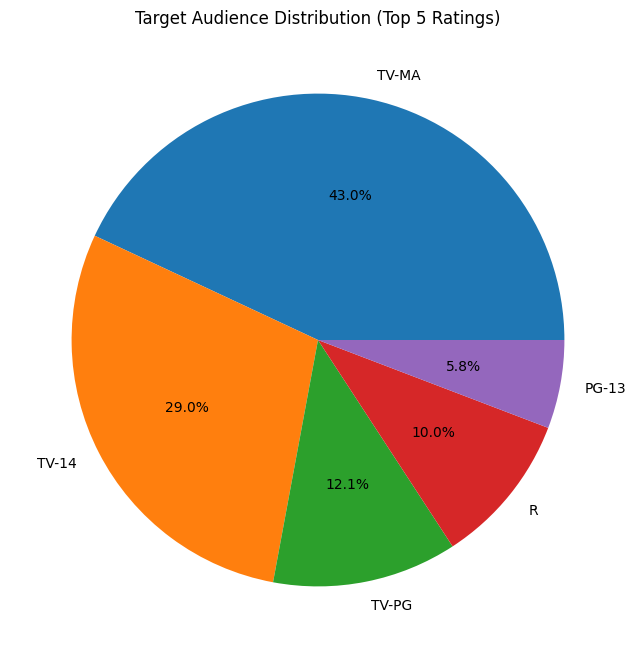

In [ ]:
import matplotlib.pyplot as plt

# Get the top 5 ratings
df['rating'].value_counts().head(5).plot(kind='pie',autopct='%1.1f%%', figsize=(8,8))
plt.title('Target Audience Distribution (Top 5 Ratings)')
plt.ylabel('') # Hides the 'rating' label on the side
plt.show()

Conclusion: It is clear from the results that, with approximately 70%, still Netflix is spending money on "Movies", but TV Shows plays an important role too. Apart from that, target audience is Kids focused titles.